<a href="https://colab.research.google.com/github/andhykavireza/tugas-3-kecerdasan-buatan/blob/main/tugas_3_fuzzy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def triangle(x, a, b, c, d, e):
    if x < a: return float(d)
    elif a <= x <= b:
        return (x - a) / (b - a) if b > a else 1.0
    elif b < x <= c:
        return (c - x) / (c - b) if c > b else 1.0
    elif x > c: return float(e)
    else: return 0.0

# Plotting
vectorized_triangle = np.vectorize(triangle)

# Definisi Singleton Output
output_values = {
    'Basic': 10,    # Juta IDR
    'Premium': 20,  # Juta IDR
    'Platinum': 30  # Juta IDR
}

# Proses Fuzzifikasi
def calculate_price(area, daya):
    mu_area = {
        'sedikit': triangle(area, 0, 0, 20, 1, 0),
        'sedang': triangle(area, 10, 20, 30, 0, 0),
        'banyak': triangle(area, 20, 40, 40, 0, 1)
    }

    mu_daya = {
        'kecil': triangle(daya, 0, 0, 10, 1, 0),
        'menengah': triangle(daya, 5, 10, 15, 0, 0),
        'besar': triangle(daya, 10, 20, 20, 0, 1)
    }

    # Aturan Fuzzy (Rule Base) - Matriks 3x3
    rules = [
        ('sedikit', 'kecil', 'Basic'),
        ('sedikit', 'menengah', 'Basic'),
        ('sedikit', 'besar', 'Premium'), # Rule Wajib
        ('sedang', 'kecil', 'Basic'),
        ('sedang', 'menengah', 'Premium'),
        ('sedang', 'besar', 'Platinum'),
        ('banyak', 'kecil', 'Premium'),
        ('banyak', 'menengah', 'Platinum'),
        ('banyak', 'besar', 'Platinum')
    ]

    # Defuzzifikasi (Weighted Average)
    num = 0
    den = 0

    print(f"--- Evaluasi Aturan Aktif (Input: Area={area}, Daya={daya}) ---")
    for r_area, r_daya, out_class in rules:
        w = min(mu_area[r_area], mu_daya[r_daya])

        if w > 0:
            z = output_values[out_class]
            num += w * z
            den += w
            print(f"IF Area {r_area} AND Daya {r_daya} THEN {out_class} | Bobot: {w:.2f}")

    if den == 0: return 0
    return num / den

# Contoh kasus
input_area = 15  # Contoh luasan m2
input_daya = 12  # Contoh daya kWp

harga_akhir = calculate_price(input_area, input_daya)
print(f"\nHasil Akhir Harga Paket: Rp {harga_akhir:.2f} Juta")

--- Evaluasi Aturan Aktif (Input: Area=15, Daya=12) ---
IF Area sedikit AND Daya menengah THEN Basic | Bobot: 0.25
IF Area sedikit AND Daya besar THEN Premium | Bobot: 0.20
IF Area sedang AND Daya menengah THEN Premium | Bobot: 0.50
IF Area sedang AND Daya besar THEN Platinum | Bobot: 0.20

Hasil Akhir Harga Paket: Rp 19.57 Juta


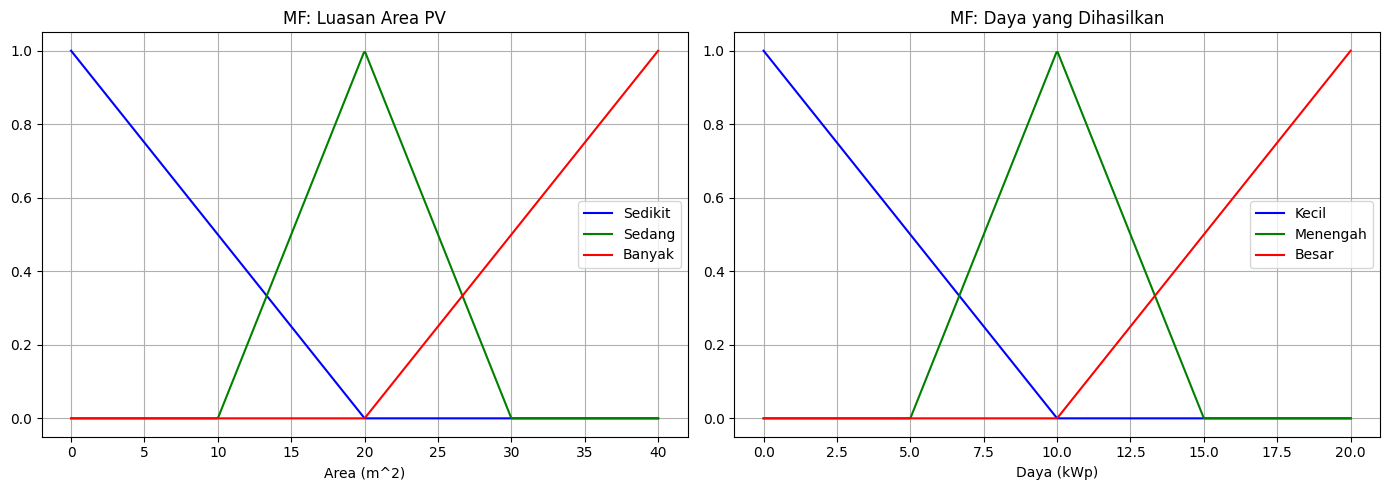

In [ ]:
def plot_mfs():
    x_area = np.linspace(0, 40, 500)
    x_daya = np.linspace(0, 20, 500) # Increased range for daya to cover all MFs properly

    plt.figure(figsize=(14, 5))

    # Plot Luasan Area
    plt.subplot(1, 2, 1)
    plt.plot(x_area, vectorized_triangle(x_area, 0, 0, 20, 1, 0), label='Sedikit', color='blue')
    plt.plot(x_area, vectorized_triangle(x_area, 10, 20, 30, 0, 0), label='Sedang', color='green')
    plt.plot(x_area, vectorized_triangle(x_area, 20, 40, 40, 0, 1), label='Banyak', color='red')
    plt.title('MF: Luasan Area PV')
    plt.xlabel('Area (m^2)')
    plt.legend()
    plt.grid(True)

    # Plot Daya
    plt.subplot(1, 2, 2)
    plt.plot(x_daya, vectorized_triangle(x_daya, 0, 0, 10, 1, 0), label='Kecil', color='blue')
    plt.plot(x_daya, vectorized_triangle(x_daya, 5, 10, 15, 0, 0), label='Menengah', color='green')
    plt.plot(x_daya, vectorized_triangle(x_daya, 10, 20, 20, 0, 1), label='Besar', color='red')
    plt.title('MF: Daya yang Dihasilkan')
    plt.xlabel('Daya (kWp)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_mfs()